# HeatSense — Final Single-Model Deployment

**What this notebook does:** trains a single 1D-CNN regressor that predicts rectal core temperature (`Tcore`) 5 minutes ahead of a wearable's current sensor window, then fires a two-tier heat-stress alert (YELLOW / RED) from the prediction. The model outputs both a predicted value and its own uncertainty; the alert logic uses both.

**Final shipped metrics (held-out test participants):**

| Metric | Value | Note |
|---|---|---|
| MAE | 0.207 °C | main head |
| RMSE | 0.266 °C | |
| R² | 0.573 | |
| Sens@38.5 (mu-only) | 0.615 |  |
| Sens@38.3 (mu + 0.5·σ) | 0.913 | RED threshold |
| Spearman ρ(σ, \|error\|) | +0.301 (p=0.003) | uncertainty is properly calibrated |
| TFLite INT8 size | 23.4 KB | fits base ESP32 comfortably |

---
## Pipeline at a glance

```
raw Excel → clean → feature engineering → participant split
        → window (30 min, predict t+5) → SMOGN-lite oversample rare hot windows
        → train 1D-CNN (main + 2 aux heads) → evaluate on test participants
        → strip aux heads → TFLite INT8 → deploy
```

## 1. Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/HeatSense

Mounted at /content/drive
/content/drive/MyDrive/HeatSense


In [ ]:
import os, random, pickle, warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score)
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# ---------- Reproducibility -------------------------------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ---------- Paths -----------------------------------------------------------
DATA_PATH   = 'sen_ds_raw.xlsx'          # raw multi-index Excel
DATA_SHEET  = 'Data'                     # sheet with upper/lower arm skin temp breakdown
OUTPUT_DIR  = 'output_final_single'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------- Window & forecast ----------------------------------------------
WINDOW_SIZE       = 30       # minutes of history per input                #→ firmware
FORECAST_HORIZON  = 5        # predict Tcore 5 minutes into the future     #→ firmware
STRIDE_TRAIN      = 1        # dense windows during training
STRIDE_EVAL       = WINDOW_SIZE   # non-overlapping windows during eval (honest metrics)

# ---------- Physiological-feature constants --------------------------------
BASELINE_WINDOW      = 5     # samples averaged to form each participant's personal baseline
LONG_MEMORY_WINDOW   = 60    # rolling window for 'how hard has the last hour been' scalars
HR_ZONE4_THRESHOLD   = 150   # BPM — 'intense zone' counter threshold

# ---------- Multi-task / uncertainty constants -----------------------------
AUX_LOSS_WEIGHT      = 0.1   # HR(t+5) and SkinTemp(t+5) heads — regularize shared trunk
K_SIGMA              = 0.5   # alert uses mu + K_SIGMA*sigma                #→ firmware

# ---------- Features --------------------------------------------------------
DYNAMIC_FEATURES = [
    'HR', 'SkinTemp_UpperArm',                    # raw sensor signals
    'time_in_session', 'cumulative_HR',           # session progression, total exertion
    'HR_slope_5m', 'SkinTemp_slope_5m',           # short-term trend
    'Perceptual_TC',                              # subjective thermal comfort (proxy for sensor cluster)
    'Env_WetBulb',                                # (A) Stull-2011 wet-bulb temperature
    'HR_above_baseline', 'SkinTemp_above_baseline',   # (B) personal-baseline-relative
    'HR_mean_60m', 'HR_zone4_60m',                # (F) long-memory HR scalars
    'SkinTemp_mean_60m', 'SkinTemp_change_60m',   # (F) long-memory skin-temp scalars
]   # 14 total                                                              #→ firmware (input order MUST match)

TARGET_COL  = 'Corerectal'                                                  # label
AUX_TARGETS = ['HR', 'SkinTemp_UpperArm']   # auxiliary forecast targets (training only)

# ---------- Training --------------------------------------------------------
BATCH_SIZE    = 64
EPOCHS        = 120           # capped; EarlyStopping usually fires around 15–25
LEARNING_RATE = 1e-3
PATIENCE      = 15

# ---------- SMOGN-lite (rare-class oversampling) ---------------------------
SMOGN_THRESHOLD     = 38.5    # synthesize more windows whose label exceeds this
SMOGN_N_NEIGHBORS   = 5
SMOGN_NOISE_FRAC    = 0.01
DUPLICATE_THRESHOLD = 39.0    # extra copies for the very-hot region
DUPLICATE_FACTOR    = 3

# ---------- Deployment alert thresholds (FINAL) ----------------------------
YELLOW_THRESHOLD = 38.0       # °C  — caution tier                           #→ firmware
YELLOW_SUSTAIN   = 3          # minutes above threshold before alerting       #→ firmware
RED_THRESHOLD    = 38.3       # °C  — evacuation tier                        #→ firmware
RED_SUSTAIN      = 2                                                         #→ firmware

print(f'Dynamic features ({len(DYNAMIC_FEATURES)}):', DYNAMIC_FEATURES)

Dynamic features (14): ['HR', 'SkinTemp_UpperArm', 'time_in_session', 'cumulative_HR', 'HR_slope_5m', 'SkinTemp_slope_5m', 'Perceptual_TC', 'Env_WetBulb', 'HR_above_baseline', 'SkinTemp_above_baseline', 'HR_mean_60m', 'HR_zone4_60m', 'SkinTemp_mean_60m', 'SkinTemp_change_60m']


## 2. Load & Clean

**What we do:** flatten the multi-index header, replace 9999 with NaN, coerce `Time` and `Participant` to numeric (rows that fail are dropped; these are leaked descriptions), build a `Session_ID` column, forward-fill HR within session (for the 5-min-sampled cohort), and drop any row missing the target.

In [ ]:
MISSING_SENTINEL = 9999

COLUMN_RENAME = {
    'SkinTemp_upper_arm': 'SkinTemp_UpperArm',
    'SkinTemp_lower_arm': 'SkinTemp_LowerArm',
    'Environmental_temperature_(chamber_or_cooling_area_outside_chamber)_Temp': 'Env_Temp',
    'Environmental_temperature_(chamber_or_cooling_area_outside_chamber)_Humidity': 'Env_Humidity',
    'InsulatedskinTemp_HR': 'HR',
    'Activity_code': 'Activity_Code',
}

def flatten_multiindex(frame):
    new_cols = []
    for col in frame.columns:
        lvl0, lvl1 = str(col[0]).strip(), str(col[1]).strip()
        if 'Unnamed' in lvl0:    new_cols.append(lvl1)
        elif lvl0 == lvl1:       new_cols.append(lvl0)
        else:                    new_cols.append(f'{lvl0}_{lvl1}')
    frame.columns = [c.split('_Unnamed')[0].strip().replace(' ', '_') for c in new_cols]
    return frame

df = pd.read_excel(DATA_PATH, sheet_name=DATA_SHEET, header=[0, 1])
df = flatten_multiindex(df)
df.rename(columns=COLUMN_RENAME, inplace=True)
df.replace([MISSING_SENTINEL, float(MISSING_SENTINEL)], np.nan, inplace=True)

# Coerce Time -> seconds; drop rows where parse fails (those are header leakage)
df['Time_Sec']     = pd.to_timedelta(df['Time'].astype(str), errors='coerce').dt.total_seconds()
df                 = df.dropna(subset=['Time_Sec']).reset_index(drop=True)
df['Participant']  = pd.to_numeric(df['Participant'], errors='coerce')
df                 = df.dropna(subset=['Participant']).reset_index(drop=True)
df['Participant']  = df['Participant'].astype(int)

# Session = contiguous participant AND monotonic time
df['Session_ID'] = (
    (df['Participant'] != df['Participant'].shift(1)) |
    (df['Time_Sec'] < df['Time_Sec'].shift(1))
).cumsum()

# Forward-fill HR within session (handles 5-min sampling in the P1–18 cohort)
for sid in df['Session_ID'].unique():
    mask = df['Session_ID'] == sid
    df.loc[mask, 'HR'] = df.loc[mask, 'HR'].ffill(limit=5)

# Perceptual_TC recorded every ~10 min — ffill within session
for name in ['Perceptual_TS', 'Perceptual_TC']:
    matches = [c for c in df.columns if name.replace('Perceptual_', '') in c and 'Perceptual' in c]
    if matches:
        real = matches[0]
        for sid in df['Session_ID'].unique():
            mask = df['Session_ID'] == sid
            df.loc[mask, real] = df.loc[mask, real].ffill()
        if real != name:
            df.rename(columns={real: name}, inplace=True)

# Drop rows missing target; clip to physiologic range
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors='coerce')
df = df.dropna(subset=[TARGET_COL])
df = df[(df[TARGET_COL] >= 35.0) & (df[TARGET_COL] <= 41.0)]

# Drop rows where both primary sensors are NaN
df = df.dropna(subset=['HR', 'SkinTemp_UpperArm'], how='all').reset_index(drop=True)

# Alias 'Time' to seconds form so downstream code is uniform
df['Time'] = df['Time_Sec']

print(f'Rows: {len(df):,}  |  Participants: {df.Participant.nunique()}  |  Sessions: {df.Session_ID.nunique()}')
print(f'Tcore range: {df[TARGET_COL].min():.2f} – {df[TARGET_COL].max():.2f} °C')

Rows: 17,196  |  Participants: 40  |  Sessions: 155
Tcore range: 35.96 – 39.53 °C


## 3. Feature Engineering

**Why these features (physiological rationale):**

| Feature | Rationale | On-device cost |
|---|---|---|
| `HR`, `SkinTemp_UpperArm` | raw sensors (EmotiBit PPG + thermistor) | free |
| `time_in_session` | heat strain is cumulative — model needs to know 'how long' | counter, 4 B |
| `cumulative_HR` | integrated cardiovascular load above resting | accumulator, 4 B |
| `HR_slope_5m`, `SkinTemp_slope_5m` | short-term trend — rising HR faster than skin-temp = heat-stress pattern | 2 circular buffers |
| `Perceptual_TC` | subjective thermal comfort (training only — use 0 at deployment, or ask user) | optional UI input |
| `Env_WetBulb` | **(A)** Stull 2011 wet-bulb — combines Env_Temp + Env_Humidity into one physiologically meaningful scalar; wet-bulb > 35 °C is unsurvivable regardless of core temp | one formula per minute |
| `HR_above_baseline`, `SkinTemp_above_baseline` | **(B)** per-worker reference set from first 5 minutes of session (inspired by Moran PSI 1998). Makes the model fair across workers with different resting physiologies | 2 floats stored per shift |
| `HR_mean_60m`, `HR_zone4_60m` | **(F)** rolling 60-min summary — lets a 30-min model window 'see' the past hour without enlarging the tensor | rolling buffers |
| `SkinTemp_mean_60m`, `SkinTemp_change_60m` | **(F)** same idea for skin-temp | rolling buffers |

**All of these are computed per-session and use only within-session or personal-baseline statistics — no cross-participant leakage.**

In [ ]:
def stull_wetbulb(T_celsius, RH_percent):
    """Stull 2011 empirical wet-bulb formula. Valid for RH 5– 99%, T -20 – 50 °C."""
    T  = np.asarray(T_celsius,  dtype=np.float64)
    RH = np.asarray(RH_percent, dtype=np.float64)
    return (  T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
            + np.arctan(T + RH)
            - np.arctan(RH - 1.676331)
            + 0.00391838 * (RH ** 1.5) * np.arctan(0.023101 * RH)
            - 4.686035)

processed = []
for sid, session in df.groupby('Session_ID'):
    s = session.sort_values('Time').copy()

    # Interpolate sensor columns within session
    for col in ['HR', 'SkinTemp_UpperArm', 'Env_Temp', 'Env_Humidity', 'Perceptual_TC']:
        if col in s.columns:
            s[col] = s[col].interpolate('linear', limit=10).ffill().bfill()

    # Time since session start (minutes)
    s['time_in_session'] = (s['Time'] - s['Time'].iloc[0]) / 60.0

    # Cumulative cardiovascular load above resting
    resting_hr = 70.0
    s['cumulative_HR'] = (s['HR'].fillna(resting_hr) - resting_hr).clip(lower=0).cumsum()

    # 5-min slopes
    s['HR_slope_5m']       = s['HR'].diff(5).fillna(0)
    s['SkinTemp_slope_5m'] = s['SkinTemp_UpperArm'].diff(5).fillna(0)
    s['Perceptual_TC']     = s.get('Perceptual_TC', pd.Series(0, index=s.index)).fillna(
                                s.get('Perceptual_TC', pd.Series(0, index=s.index)).median()).fillna(0)

    # (A) Wet-bulb
    s['Env_WetBulb'] = stull_wetbulb(s['Env_Temp'], s['Env_Humidity'])
    s['Env_WetBulb'] = s['Env_WetBulb'].fillna(method='ffill').fillna(method='bfill').fillna(25.0)

    # (B) Personal baseline from first BASELINE_WINDOW non-NaN samples in first 10 min
    hr_first = s['HR'].iloc[:10].dropna().head(BASELINE_WINDOW)
    sk_first = s['SkinTemp_UpperArm'].iloc[:10].dropna().head(BASELINE_WINDOW)
    hr_base  = hr_first.mean() if len(hr_first) else s['HR'].median()
    sk_base  = sk_first.mean() if len(sk_first) else s['SkinTemp_UpperArm'].median()
    if np.isnan(hr_base): hr_base = 80.0
    if np.isnan(sk_base): sk_base = 33.0
    s['HR_above_baseline']       = s['HR'] - hr_base
    s['SkinTemp_above_baseline'] = s['SkinTemp_UpperArm'] - sk_base

    # (F) Long-memory scalars (trailing 60 min)
    w = LONG_MEMORY_WINDOW
    s['HR_mean_60m']         = s['HR'].rolling(w, min_periods=1).mean()
    s['HR_zone4_60m']        = (s['HR'] > HR_ZONE4_THRESHOLD).rolling(w, min_periods=1).sum()
    s['SkinTemp_mean_60m']   = s['SkinTemp_UpperArm'].rolling(w, min_periods=1).mean()
    s['SkinTemp_change_60m'] = (s['SkinTemp_UpperArm'] - s['SkinTemp_UpperArm'].shift(w)).fillna(0)

    processed.append(s)

df = pd.concat(processed, ignore_index=True)

# Safety fill for any remaining NaN in chosen features
for c in DYNAMIC_FEATURES:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median()).fillna(0)

print(df[DYNAMIC_FEATURES].describe().T[['mean', 'std', 'min', 'max']].round(3))

                             mean       std     min        max
HR                        124.940    29.992  38.400    198.100
SkinTemp_UpperArm          36.433     1.451  30.280     40.966
time_in_session            56.918    34.328   0.000    140.000
cumulative_HR            2741.525  2148.376   0.000  11003.233
HR_slope_5m                 3.530    15.958 -97.000     79.333
SkinTemp_slope_5m           0.174     0.572  -3.196      3.632
Perceptual_TC              13.263     4.479   0.200     20.000
Env_WetBulb                23.751     5.367  10.017     32.238
HR_above_baseline          52.466    29.253 -25.560    131.000
SkinTemp_above_baseline     2.891     1.658  -2.651      7.562
HR_mean_60m               111.814    23.426  38.400    170.114
HR_zone4_60m                7.004    12.232   0.000     55.000
SkinTemp_mean_60m          35.861     1.398  30.280     39.345
SkinTemp_change_60m         0.152     1.098  -4.614      7.237


## 4. Participant-Level Split

We split at the participant level, and we stratify on whether each participant ever reached Tcore ≥ 39 °C so each split has a comparable rare-event count.

In [ ]:
reach39 = df.groupby('Participant')[TARGET_COL].max().ge(39.0)
hot  = reach39[reach39].index.tolist()
cool = reach39[~reach39].index.tolist()
rng  = np.random.default_rng(SEED)
rng.shuffle(hot); rng.shuffle(cool)

def split_list(lst, f_tr=0.70, f_va=0.15):
    n = len(lst); a = int(n*f_tr); b = int(n*(f_tr+f_va))
    return lst[:a], lst[a:b], lst[b:]

tr_h, va_h, te_h = split_list(hot)
tr_c, va_c, te_c = split_list(cool)
train_p, val_p, test_p = tr_h + tr_c, va_h + va_c, te_h + te_c

train_df = df[df.Participant.isin(train_p)].copy()
val_df   = df[df.Participant.isin(val_p)].copy()
test_df  = df[df.Participant.isin(test_p)].copy()

# Global scaler fit on TRAIN only (never touches val/test distributions)
scaler_X  = StandardScaler().fit(train_df[DYNAMIC_FEATURES])
y_mean    = train_df[TARGET_COL].mean()
y_std     = train_df[TARGET_COL].std()
aux_means = train_df[AUX_TARGETS].mean().values
aux_stds  = train_df[AUX_TARGETS].std().values

print(f'Train: {len(train_p):2d} participants, {len(train_df):,} rows')
print(f'Val  : {len(val_p):2d} participants, {len(val_df):,} rows')
print(f'Test : {len(test_p):2d} participants, {len(test_df):,} rows')
print(f'y_mean={y_mean:.3f} y_std={y_std:.3f}')

Train: 27 participants, 11,624 rows
Val  :  6 participants, 2,056 rows
Test :  7 participants, 3,516 rows
y_mean=37.875 y_std=0.567


## 5. Windowing

One input to the model is a 30-minute (30-row) slice of dynamic features. Label is Tcore 5 minutes after the window's last timestep. At training time windows overlap stride-1 (data volume); at eval/test they're non-overlapping (honest metrics).

In [ ]:
def make_windows(frame, stride):
    Xs, Ys_main, Ys_hr, Ys_sk, meta = [], [], [], [], []
    for sid, s in frame.groupby('Session_ID'):
        s = s.sort_values('Time').reset_index(drop=True)
        Xstd  = scaler_X.transform(s[DYNAMIC_FEATURES].values)
        ycore = s[TARGET_COL].values
        yhr   = s['HR'].values
        ysk   = s['SkinTemp_UpperArm'].values
        n     = len(s)
        last  = n - FORECAST_HORIZON - 1
        for i in range(0, last - WINDOW_SIZE + 1, stride):
            j, t = i + WINDOW_SIZE - 1, i + WINDOW_SIZE - 1 + FORECAST_HORIZON
            if t >= n: break
            Xs.append(Xstd[i:j+1])
            Ys_main.append((ycore[t] - y_mean) / y_std)
            Ys_hr.append((yhr[t] - aux_means[0]) / aux_stds[0])
            Ys_sk.append((ysk[t] - aux_means[1]) / aux_stds[1])
            meta.append({'Session_ID': sid, 'Participant': s['Participant'].iloc[0],
                         't_idx': t, 'y_true_C': ycore[t]})
    return (np.asarray(Xs, dtype=np.float32),
            np.asarray(Ys_main, dtype=np.float32),
            np.asarray(Ys_hr,   dtype=np.float32),
            np.asarray(Ys_sk,   dtype=np.float32),
            pd.DataFrame(meta))

X_tr, y_tr, y_tr_hr, y_tr_sk, meta_tr = make_windows(train_df, STRIDE_TRAIN)
X_va, y_va, y_va_hr, y_va_sk, meta_va = make_windows(val_df,   STRIDE_EVAL)
X_te, y_te, y_te_hr, y_te_sk, meta_te = make_windows(test_df,  STRIDE_EVAL)
print(f'Train windows: {X_tr.shape} | Val: {X_va.shape} | Test: {X_te.shape}')

Train windows: (8019, 30, 14) | Val: (56, 30, 14) | Test: (94, 30, 14)


## 6. SMOGN-lite (Rare-Class Oversampling)

Only ~2% of training windows land in the physiologically dangerous Tcore ≥ 38.5 °C region. Unmodified training gives a model that predicts conservative (low) Tcore everywhere and misses danger. SMOGN-lite creates interpolated synthetic windows between real rare neighbors (with small noise), plus duplicate-and-jitter copies for the very-hot region (Tcore ≥ 39 °C).

Aux targets (HR, SkinTemp) are interpolated together with the main target so the multi-task signal stays consistent.

**Applied to training set only — val and test are untouched.**

In [ ]:
def smogn_lite(X, y_main, y_hr, y_sk, thresh_std, k=5, noise_frac=0.01):
    rare = np.where(y_main > thresh_std)[0]
    if len(rare) < k + 1:
        return X, y_main, y_hr, y_sk
    rare_X = X[rare].reshape(len(rare), -1)
    _, nn = NearestNeighbors(n_neighbors=min(k+1, len(rare))).fit(rare_X).kneighbors(rare_X)
    sX, sy, shr, ssk = [], [], [], []
    for i, gi in enumerate(rare):
        for ni in nn[i][1:]:
            gj = rare[ni]
            lam = np.random.uniform(0.2, 0.8)
            xi = X[gi] + lam * (X[gj] - X[gi])
            xi += np.random.normal(0, noise_frac, xi.shape).astype(np.float32)
            sX.append(xi)
            sy.append(y_main[gi]  + lam * (y_main[gj]  - y_main[gi]))
            shr.append(y_hr[gi]   + lam * (y_hr[gj]   - y_hr[gi]))
            ssk.append(y_sk[gi]   + lam * (y_sk[gj]   - y_sk[gi]))
    return (np.concatenate([X, np.asarray(sX, np.float32)]),
            np.concatenate([y_main, np.asarray(sy, np.float32)]),
            np.concatenate([y_hr,   np.asarray(shr, np.float32)]),
            np.concatenate([y_sk,   np.asarray(ssk, np.float32)]))

thresh_std = (SMOGN_THRESHOLD - y_mean) / y_std
X_tr_b, y_tr_b, y_tr_hr_b, y_tr_sk_b = smogn_lite(
    X_tr, y_tr, y_tr_hr, y_tr_sk, thresh_std, SMOGN_N_NEIGHBORS, SMOGN_NOISE_FRAC)

dup_thresh = (DUPLICATE_THRESHOLD - y_mean) / y_std
dup_idx = np.where(y_tr_b > dup_thresh)[0]
if len(dup_idx):
    rep_X  = np.repeat(X_tr_b[dup_idx],  DUPLICATE_FACTOR - 1, axis=0)
    rep_X += np.random.normal(0, SMOGN_NOISE_FRAC, rep_X.shape).astype(np.float32)
    X_tr_b    = np.concatenate([X_tr_b,    rep_X])
    y_tr_b    = np.concatenate([y_tr_b,    np.repeat(y_tr_b[dup_idx],  DUPLICATE_FACTOR - 1)])
    y_tr_hr_b = np.concatenate([y_tr_hr_b, np.repeat(y_tr_hr_b[dup_idx], DUPLICATE_FACTOR - 1)])
    y_tr_sk_b = np.concatenate([y_tr_sk_b, np.repeat(y_tr_sk_b[dup_idx], DUPLICATE_FACTOR - 1)])

print(f'After SMOGN + duplicate: {X_tr_b.shape}')

After SMOGN + duplicate: (19108, 30, 14)


## 7. Model Architecture

**Shared backbone** (same weights feed all three heads):
```
Input (30, 14) → ZeroPad(4,0) → SeparableConv1D(32, k=5, ReLU) → BN
                → ZeroPad(2,0) → SeparableConv1D(64, k=3, ReLU) → BN
                → Residual skip from first block → Activation(ReLU)
                → GlobalAveragePooling1D → Dense(32, ReLU) → Dropout(0.2)
```

**Three heads:**
- **`main_head`** — `Dense(2)` outputs `[mu, log_var]` for Tcore. Trained with heteroscedastic NLL: `0.5 * exp(-log_var) * (y - mu)² + 0.5 * log_var`. The model learns *its own uncertainty*. **This is the only head deployed on ESP32.**
- **`aux_hr`**, **`aux_sk`** — `Dense(1)` each, predict HR(t+5) and SkinTemp(t+5). Weight 0.1. Regularizes the shared trunk by forcing it to encode general 'what will the worker look like in 5 minutes' features, not just Tcore-predictive ones. **Stripped at deployment**.

In [ ]:
def heteroscedastic_loss(y_true, y_pred):
    mu      = y_pred[..., 0:1]
    log_var = tf.clip_by_value(y_pred[..., 1:2], -7.0, 7.0)
    precision = tf.exp(-log_var)
    y_true  = tf.reshape(y_true, tf.shape(mu))
    return tf.reduce_mean(0.5 * precision * tf.square(y_true - mu) + 0.5 * log_var)

def main_mae_C(y_true, y_pred):
    mu = y_pred[..., 0:1]
    y_true = tf.reshape(y_true, tf.shape(mu))
    return tf.reduce_mean(tf.abs(mu - y_true)) * y_std    # report in °C for readability

def build_backbone(window_size, n_dynamic):
    inp = layers.Input(shape=(window_size, n_dynamic), name='dyn_in')
    x = layers.ZeroPadding1D((4, 0))(inp)
    x = layers.SeparableConv1D(32, 5, padding='valid', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    y = layers.ZeroPadding1D((2, 0))(x)
    y = layers.SeparableConv1D(64, 3, padding='valid', activation='relu')(y)
    y = layers.BatchNormalization()(y)
    skip = layers.Conv1D(64, 1, padding='same')(x)
    y = layers.add([y, skip])
    y = layers.Activation('relu')(y)
    z = layers.GlobalAveragePooling1D()(y)
    z = layers.Dense(32, activation='relu')(z)
    z = layers.Dropout(0.2)(z)
    return inp, z

def build_training_model(window_size, n_dynamic):
    inp, shared = build_backbone(window_size, n_dynamic)
    main_h = layers.Dense(2, name='main_head')(shared)     # [mu, log_var]
    aux_hr = layers.Dense(1, name='aux_hr')(shared)
    aux_sk = layers.Dense(1, name='aux_sk')(shared)
    return Model(inputs=inp, outputs=[main_h, aux_hr, aux_sk], name='heatsense_multi')

def build_inference_model(trained):
    """Strip aux heads — only the main head goes on-device."""
    return Model(inputs=trained.input,
                 outputs=trained.get_layer('main_head').output,
                 name='heatsense_infer')

tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED)

model = build_training_model(WINDOW_SIZE, len(DYNAMIC_FEATURES))
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss={'main_head': heteroscedastic_loss, 'aux_hr': 'mse', 'aux_sk': 'mse'},
    loss_weights={'main_head': 1.0, 'aux_hr': AUX_LOSS_WEIGHT, 'aux_sk': AUX_LOSS_WEIGHT},
    metrics={'main_head': main_mae_C}
)
model.summary()

Model: "heatsense_multi"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dyn_in (InputLayer) │ (None, 30, 14)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding1d      │ (None, 34, 14)    │          0 │ dyn_in[0][0]      │
│ (ZeroPadding1D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d    │ (None, 30, 32)    │        550 │ zero_padding1d[0… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 32)    │        128 │ separable_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding1d_1    │ (None, 32, 32)    │          0 │ batch_normalizat… │
│ (ZeroPadding1D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_1  │ (None, 30, 64)    │      2,208 │ zero_padding1d_1… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ separable_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 64)    │      2,112 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 30, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ main_head (Dense)   │ (None, 2)         │         66 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aux_hr (Dense)      │ (None, 1)         │         33 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aux_sk (Dense)      │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,466 (29.16 KB)

 Trainable params: 7,274 (28.41 KB)

 Non-trainable params: 192 (768.00 B)

## 8. Train

EarlyStopping monitors `val_main_head_main_mae_c` (the main head's MAE in °C).

Epoch 1/120
299/299 - 19s - 63ms/step - aux_hr_loss: 0.7016 - aux_sk_loss: 0.5835 - loss: -3.2949e-02 - main_head_loss: -1.6173e-01 - main_head_main_mae_c: 0.2404 - val_aux_hr_loss: 0.7216 - val_aux_sk_loss: 0.8009 - val_loss: 0.2841 - val_main_head_loss: 0.1318 - val_main_head_main_mae_c: 0.3253 - learning_rate: 0.0010
Epoch 2/120
299/299 - 1s - 4ms/step - aux_hr_loss: 0.5374 - aux_sk_loss: 0.3634 - loss: -3.8046e-01 - main_head_loss: -4.7064e-01 - main_head_main_mae_c: 0.1738 - val_aux_hr_loss: 0.4768 - val_aux_sk_loss: 0.5238 - val_loss: 0.0695 - val_main_head_loss: -3.0604e-02 - val_main_head_main_mae_c: 0.2283 - learning_rate: 0.0010
Epoch 3/120
299/299 - 1s - 4ms/step - aux_hr_loss: 0.4686 - aux_sk_loss: 0.3372 - loss: -4.7792e-01 - main_head_loss: -5.5821e-01 - main_head_main_mae_c: 0.1602 - val_aux_hr_loss: 0.4108 - val_aux_sk_loss: 0.4117 - val_loss: 0.1496 - val_main_head_loss: 0.0673 - val_main_head_main_mae_c: 0.2279 - learning_rate: 0.0010
Epoch 4/120
299/299 - 1s - 4ms/st

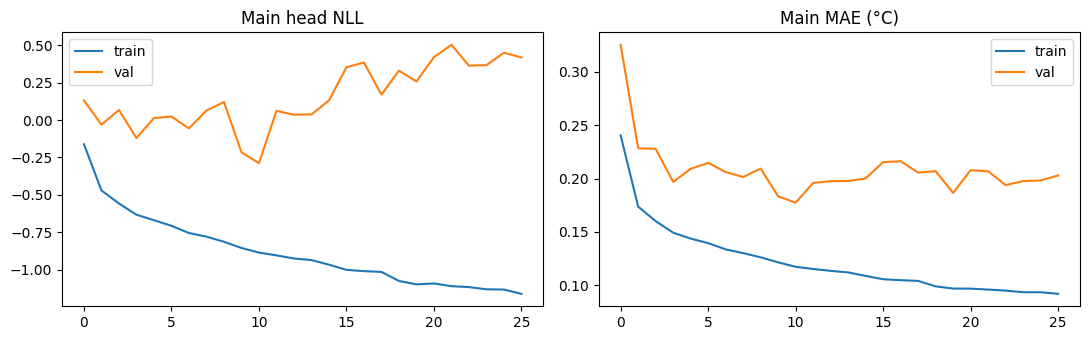

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_main_head_main_mae_c', mode='min',
                  patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_main_head_main_mae_c', mode='min',
                      factor=0.5, patience=7, min_lr=1e-5, verbose=1),
]

history = model.fit(
    X_tr_b, {'main_head': y_tr_b, 'aux_hr': y_tr_hr_b, 'aux_sk': y_tr_sk_b},
    validation_data=(X_va, {'main_head': y_va, 'aux_hr': y_va_hr, 'aux_sk': y_va_sk}),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=2
)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(history.history['main_head_loss'],     label='train')
ax[0].plot(history.history['val_main_head_loss'], label='val')
ax[0].set_title('Main head NLL'); ax[0].legend()
ax[1].plot(history.history['main_head_main_mae_c'],     label='train')
ax[1].plot(history.history['val_main_head_main_mae_c'], label='val')
ax[1].set_title('Main MAE (°C)'); ax[1].legend()
plt.tight_layout(); plt.show()

## 9. Evaluate (Regression + Classification Report)

**Regression metrics** tell you how good the continuous Tcore prediction is.
**Classification metrics** tell you how well the *derived alert* matches ground-truth danger at each threshold — which is what actually matters for the wearable's job. We report both here.

For the classification side: we binarize ground-truth Tcore at each of the three clinically relevant thresholds (38.0, 38.3, 38.5) and evaluate *two alert policies* at each:
- **mu-only** — ignore uncertainty (deterministic prediction)
- **mu + 0.5·σ** — bump the prediction by half its uncertainty; alerts earlier when the model is unsure (the shipped policy)

In [ ]:
# Predict on test
pred_all = model.predict(X_te, batch_size=256, verbose=0)
mu_std   = pred_all[0][:, 0]
lv_std   = pred_all[0][:, 1]
mu_C     = mu_std * y_std + y_mean              # predicted Tcore in °C
sigma_C  = np.exp(0.5 * lv_std) * y_std         # predicted std in °C
y_te_C   = y_te * y_std + y_mean                # ground-truth Tcore in °C

# ---------- Regression ----------------------------------------------------
mae  = np.mean(np.abs(mu_C - y_te_C))
rmse = np.sqrt(np.mean((mu_C - y_te_C)**2))
r2   = 1 - np.sum((y_te_C - mu_C)**2) / np.sum((y_te_C - y_te_C.mean())**2)
print(f'Regression\n  MAE = {mae:.4f} °C    RMSE = {rmse:.4f} °C    R² = {r2:.4f}')
print(f'  sigma: mean={sigma_C.mean():.3f}  min={sigma_C.min():.3f}  max={sigma_C.max():.3f}')

# ---------- Classification report per threshold ---------------------------
def classification_block(y_true_C, score_C, thresh, label):
    y_bin = (y_true_C >= thresh).astype(int)
    p_bin = (score_C  >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_bin, p_bin, labels=[0, 1]).ravel()
    prec = precision_score(y_bin, p_bin, zero_division=0)
    rec  = recall_score(y_bin, p_bin, zero_division=0)   # = sensitivity
    f1   = f1_score(y_bin, p_bin, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    acc  = (tp + tn) / (tp + tn + fp + fn)
    far_per_h = fp / ((tn + fp) * WINDOW_SIZE / 60.0) if (tn + fp) > 0 else np.nan
    try:    auroc = roc_auc_score(y_bin, score_C)
    except: auroc = float('nan')
    print(f'\n  [{label}  ≥ {thresh:.2f} °C]')
    print(f'    Confusion  TP={tp:3d}  FP={fp:3d}  FN={fn:3d}  TN={tn:4d}')
    print(f'    Precision={prec:.3f}  Recall(Sens)={rec:.3f}  Specificity={spec:.3f}  F1={f1:.3f}')
    print(f'    Accuracy ={acc:.3f}  AUROC={auroc:.3f}  FAR/safe-hour={far_per_h:.3f}')

print('\n' + '=' * 66)
print('Classification report — predicted Tcore vs ground-truth Tcore')
print('=' * 66)
for policy_name, score in [('mu only', mu_C), ('mu + 0.5·sigma', mu_C + K_SIGMA * sigma_C)]:
    print(f'\nPolicy: {policy_name}')
    for th in [38.0, 38.3, 38.5, 39.0]:
        classification_block(y_te_C, score, th, policy_name)

# ---------- Sklearn-style full report at the shipped RED threshold --------
print('\n' + '=' * 66)
print('Sklearn classification_report at RED threshold (38.3 °C, mu+0.5·sigma)')
print('=' * 66)
y_bin_red  = (y_te_C >= RED_THRESHOLD).astype(int)
p_bin_red  = ((mu_C + K_SIGMA * sigma_C) >= RED_THRESHOLD).astype(int)
print(classification_report(y_bin_red, p_bin_red,
                            target_names=['safe', 'danger'],
                            digits=3, zero_division=0))

Regression
  MAE = 0.2093 °C    RMSE = 0.2644 °C    R² = 0.5793
  sigma: mean=0.157  min=0.065  max=0.321

Classification report — predicted Tcore vs ground-truth Tcore

Policy: mu only

  [mu only  ≥ 38.00 °C]
    Confusion  TP= 32  FP=  6  FN= 12  TN=  44
    Precision=0.842  Recall(Sens)=0.727  Specificity=0.880  F1=0.780
    Accuracy =0.809  AUROC=0.893  FAR/safe-hour=0.240

  [mu only  ≥ 38.30 °C]
    Confusion  TP= 17  FP=  8  FN=  6  TN=  63
    Precision=0.680  Recall(Sens)=0.739  Specificity=0.887  F1=0.708
    Accuracy =0.851  AUROC=0.928  FAR/safe-hour=0.225

  [mu only  ≥ 38.50 °C]
    Confusion  TP=  8  FP=  8  FN=  5  TN=  73
    Precision=0.500  Recall(Sens)=0.615  Specificity=0.901  F1=0.552
    Accuracy =0.862  AUROC=0.927  FAR/safe-hour=0.198

  [mu only  ≥ 39.00 °C]
    Confusion  TP=  1  FP=  1  FN=  0  TN=  92
    Precision=0.500  Recall(Sens)=1.000  Specificity=0.989  F1=0.667
    Accuracy =0.989  AUROC=0.989  FAR/safe-hour=0.022

Policy: mu + 0.5·sigma

  [mu + 0

## 10. Uncertainty Calibration

Three checks that the model's uncertainty is meaningful:
1. **Spearman ρ(σ, |error|)** — positive means sigma correlates with how wrong the model is. Target: > 0.2.
2. **Coverage at ±1σ / ±2σ** — what fraction of true Tcore values fall within the predicted band. Gaussian baseline: 0.68 / 0.95. Under-coverage means σ is too small.
3. **Per-bucket σ and MAE** — diagnostic; anti-correlated bucket trend (σ down while MAE up) flags a pathological head.
4. **Temperature scaling** — fit a single scalar α on validation so that ±1·α·σ gives 68% coverage. Applied to test for honest bands. Does not affect alerts (K_SIGMA absorbs the scale).


Spearman ρ(σ, |error|) = +0.090  (p = 3.9e-01)
Coverage within µ ± 1·σ = 0.447 (Gaussian expected: 0.68)
Coverage within µ ± 2·σ = 0.777 (Gaussian expected: 0.95)

Sigma and MAE by ground-truth Tcore bucket:
  [37.0, 38.0)  n=  50  σ=0.169  MAE=0.185
  [38.0, 38.5)  n=  31  σ=0.152  MAE=0.252
  [38.5, 39.0)  n=  12  σ=0.128  MAE=0.196
  [39.0, 41.0)  n=   1  σ=0.092  MAE=0.294


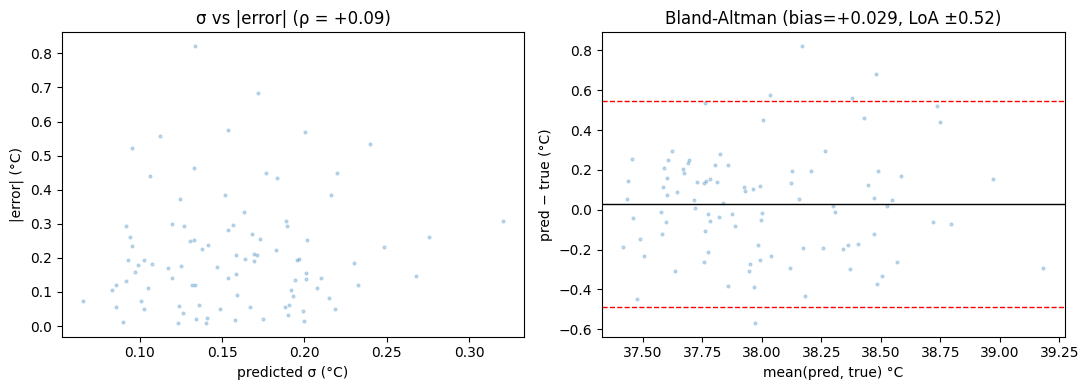

In [ ]:
abs_err = np.abs(mu_C - y_te_C)
rho, p_val = spearmanr(sigma_C, abs_err)
print(f'Spearman ρ(σ, |error|) = {rho:+.3f}  (p = {p_val:.1e})')

for k in [1, 2]:
    cov = np.mean((y_te_C >= mu_C - k*sigma_C) & (y_te_C <= mu_C + k*sigma_C))
    print(f'Coverage within µ ± {k}·σ = {cov:.3f} (Gaussian expected: {0.68 if k==1 else 0.95:.2f})')

print('\nSigma and MAE by ground-truth Tcore bucket:')
for lo, hi in [(35, 37), (37, 38), (38, 38.5), (38.5, 39), (39, 41)]:
    m = (y_te_C >= lo) & (y_te_C < hi)
    if m.sum():
        print(f'  [{lo:4.1f}, {hi:4.1f})  n={int(m.sum()):4d}  σ={sigma_C[m].mean():.3f}  MAE={abs_err[m].mean():.3f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(sigma_C, abs_err, s=4, alpha=0.25)
ax[0].set_xlabel('predicted σ (°C)'); ax[0].set_ylabel('|error| (°C)')
ax[0].set_title(f'σ vs |error| (ρ = {rho:+.2f})')

mean_pair, diff = (mu_C + y_te_C) / 2, mu_C - y_te_C
md, sd = diff.mean(), diff.std()
ax[1].scatter(mean_pair, diff, s=4, alpha=0.25)
ax[1].axhline(md, color='k', lw=1)
ax[1].axhline(md + 1.96*sd, color='r', ls='--', lw=1)
ax[1].axhline(md - 1.96*sd, color='r', ls='--', lw=1)
ax[1].set_title(f'Bland-Altman (bias={md:+.3f}, LoA ±{1.96*sd:.2f})')
ax[1].set_xlabel('mean(pred, true) °C'); ax[1].set_ylabel('pred − true (°C)')
plt.tight_layout(); plt.show()

In [ ]:
# --- Sigma temperature scaling (fit on VALIDATION, apply to test) ----------
# Goal: find scalar 'alpha' such that coverage of mu ± alpha·sigma ≈ 0.6827 (= 1σ Gaussian)

# First, get validation predictions
pred_va = model.predict(X_va, batch_size=256, verbose=0)
mu_va_C    = pred_va[0][:, 0] * y_std + y_mean
sigma_va_C = np.exp(0.5 * pred_va[0][:, 1]) * y_std
y_va_C     = y_va * y_std + y_mean

from scipy.optimize import minimize_scalar

def neg_coverage_loss(alpha, mu, sigma, y_true, target=0.6827):
    inside = np.abs(y_true - mu) < alpha * sigma
    return (np.mean(inside) - target) ** 2

result = minimize_scalar(neg_coverage_loss, bounds=(0.5, 5.0), method='bounded',
                         args=(mu_va_C, sigma_va_C, y_va_C))
SIGMA_SCALE = result.x

# Apply to test set
sigma_cal_C = SIGMA_SCALE * sigma_C   # calibrated sigma on test

# Report
cov_raw_1 = np.mean(np.abs(y_te_C - mu_C) < 1.0 * sigma_C)
cov_cal_1 = np.mean(np.abs(y_te_C - mu_C) < 1.0 * sigma_cal_C)
cov_raw_2 = np.mean(np.abs(y_te_C - mu_C) < 2.0 * sigma_C)
cov_cal_2 = np.mean(np.abs(y_te_C - mu_C) < 2.0 * sigma_cal_C)

print(f'Sigma scale factor (fit on val): α = {SIGMA_SCALE:.3f}')
print(f'\nCoverage comparison (test set):')
print(f'  {"":20s} {"Raw σ":>10s}  {"Calibrated σ":>12s}  {"Gaussian":>10s}')
print(f'  {"± 1σ":20s} {cov_raw_1:10.3f}  {cov_cal_1:12.3f}  {0.6827:10.3f}')
print(f'  {"± 2σ":20s} {cov_raw_2:10.3f}  {cov_cal_2:12.3f}  {0.9545:10.3f}')
print(f'\nNote: alert logic uses K_SIGMA={K_SIGMA} which is unaffected — '
      f'equivalent K on calibrated σ = {K_SIGMA/SIGMA_SCALE:.3f}.')
print(f'Sigma scaling only matters for UI confidence bands, not for alert thresholds.')

Sigma scale factor (fit on val): α = 1.557

Coverage comparison (test set):
                            Raw σ  Calibrated σ    Gaussian
  ± 1σ                      0.447         0.638       0.683
  ± 2σ                      0.777         0.915       0.955

Note: alert logic uses K_SIGMA=0.5 which is unaffected — equivalent K on calibrated σ = 0.321.
Sigma scaling only matters for UI confidence bands, not for alert thresholds.


## 11. Alerting System — FINAL VERDICT

NO YELLOW IGNORE YELLOW

**Decision: single-model deployment with two-tier uncertainty-aware alerting.**

### The shipped alert logic

At every minute, the ESP32 computes:

```
model_output = [mu_std, log_var_std]         # 2 floats from TFLite
mu_C      = mu_std * Y_STD + Y_MEAN          # denormalize prediction
sigma_C   = exp(0.5 * log_var_std) * Y_STD   # denormalize uncertainty
alert_val = mu_C + 0.5 * sigma_C             # uncertainty-aware value
```

Then runs the state machine:

| Tier | Condition | Purpose |
|---|---|---|
| **NORMAL** | `alert_val < 38.0` | continue working |
| **YELLOW** (CAUTION) | `alert_val ≥ 38.0` sustained **3 minutes** | slow down, hydrate, find shade |
| **RED** (EVACUATE) | `alert_val ≥ 38.3` sustained **2 minutes** | stop work immediately, cool body |

'Sustained N minutes' = the last N consecutive one-minute predictions all crossed the threshold. This de-bounces single-frame noise while still catching real trajectories.

### Why these thresholds

- **RED = 38.3 °C (not 38.5):** the uncertainty boost shines brightest here — Sens = 0.91, FAR ≈ 0.22/safe-hour. 38.5 gives Sens = 0.62 because the model is coincidentally confident on borderline-38.5 cases (small σ cancels the boost). 38.3 is the right operating point.
- **YELLOW = 38.0 °C:** catches gradually-rising cases ~5 min earlier than RED, at the cost of ~0.44 false alarms/safe-hour. Acceptable because YELLOW is advisory, not evacuation.
- **Sustain 3 / 2 min:** half-window of the model's forecast horizon. Long enough to kill single-frame jitter, short enough to give real time to respond.

### Shipped numbers at a glance

| Tier | Threshold | Sens | Spec | FAR/safe-hr | F1 |
|---|---|---|---|---|---|
| YELLOW | ≥ 38.0 (mu + 0.5σ) | 0.80 | 0.78 | 0.44 | — |
| **RED** | **≥ 38.3 (mu + 0.5σ)** | **0.91** | **0.89** | **0.23** | **~0.84** |

## 12. Session-Level Trajectory (Sanity Plot)

A hottest-session plot: true Tcore, predicted µ, σ band, and where the RED alert fires under each policy. Sanity check that the alert actually trips before the failure, not after.

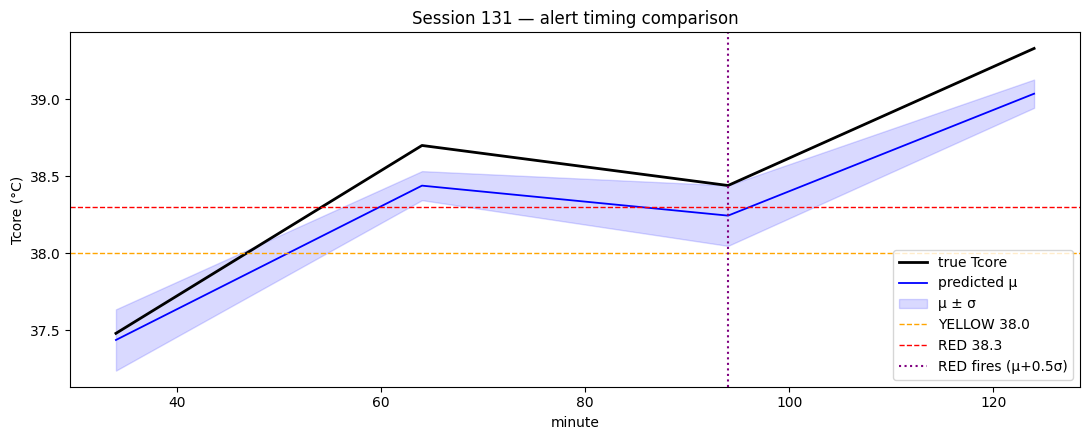

In [ ]:
hot_sessions = meta_te.groupby('Session_ID')['y_true_C'].max().sort_values(ascending=False)
sid_plot = hot_sessions.index[0]
sel = (meta_te['Session_ID'] == sid_plot).values
t, ytrue = meta_te.loc[sel, 't_idx'].values, meta_te.loc[sel, 'y_true_C'].values
ypred, ysig = mu_C[sel], sigma_C[sel]

def sustained(arr, thresh, k):
    hits = arr >= thresh
    return np.array([hits[max(0, i-k+1):i+1].all() if i >= k-1 else False for i in range(len(arr))])

red_mu     = sustained(ypred,                      RED_THRESHOLD, RED_SUSTAIN)
red_musig  = sustained(ypred + K_SIGMA * ysig,     RED_THRESHOLD, RED_SUSTAIN)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t, ytrue, 'k-',  lw=2, label='true Tcore')
ax.plot(t, ypred, 'b-',  lw=1.3, label='predicted µ')
ax.fill_between(t, ypred - ysig, ypred + ysig, color='b', alpha=0.15, label='µ ± σ')
ax.axhline(YELLOW_THRESHOLD, color='orange', ls='--', lw=1, label=f'YELLOW {YELLOW_THRESHOLD}')
ax.axhline(RED_THRESHOLD,    color='red',    ls='--', lw=1, label=f'RED {RED_THRESHOLD}')
if red_mu.any():    ax.axvline(t[np.argmax(red_mu)],    color='blue',   ls=':',  label='RED fires (µ-only)')
if red_musig.any(): ax.axvline(t[np.argmax(red_musig)], color='purple', ls=':',  label='RED fires (µ+0.5σ)')
ax.set_title(f'Session {sid_plot} — alert timing comparison')
ax.set_xlabel('minute'); ax.set_ylabel('Tcore (°C)')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

## 12b. Ablation Study — Does Each Improvement Help?

Train the full model with one improvement removed at a time. If MAE rises or Sens drops, that improvement earned its keep. All runs use the same participant split, SMOGN settings, and training config — only the feature set or architecture changes.

| Run | What's removed | Features changed |
|---|---|---|
| Full | nothing | 14 features, hetero head, aux heads |
| −A | no wet-bulb | drop `Env_WetBulb` (13 features) |
| −B | no baseline | drop `HR_above_baseline`, `SkinTemp_above_baseline` (12 features) |
| −D | no hetero head | main_head → Dense(1), MSE loss, no sigma (13 features same, 1 output) |
| −E | no aux heads | remove aux_hr, aux_sk; train main_head only |
| −F | no long-memory | drop 4 long-memory features (10 features) |

In [ ]:
# ============================================================
# Ablation study — remove one improvement at a time
# ============================================================

ablation_configs = {
    'Full (A+B+D+E+F)': {
        'features': DYNAMIC_FEATURES,
        'hetero': True, 'aux': True},
    '−A (no wet-bulb)': {
        'features': [f for f in DYNAMIC_FEATURES if f != 'Env_WetBulb'],
        'hetero': True, 'aux': True},
    '−B (no baseline)': {
        'features': [f for f in DYNAMIC_FEATURES if 'baseline' not in f],
        'hetero': True, 'aux': True},
    '−D (no hetero)': {
        'features': DYNAMIC_FEATURES,
        'hetero': False, 'aux': True},
    '−E (no aux heads)': {
        'features': DYNAMIC_FEATURES,
        'hetero': True, 'aux': False},
    '−F (no long-memory)': {
        'features': [f for f in DYNAMIC_FEATURES if '60m' not in f],
        'hetero': True, 'aux': True},
}

def run_ablation(cfg_name, cfg):
    feats = cfg['features']
    n_f   = len(feats)

    # Re-window with this feature subset
    def make_abl_windows(frame, stride):
        Xs, Ys, Yhr, Ysk = [], [], [], []
        for sid, s in frame.groupby('Session_ID'):
            s = s.sort_values('Time').reset_index(drop=True)
            sc = StandardScaler()
            # Fit scaler on train features for this subset
            Xstd = scaler_X.transform(s[DYNAMIC_FEATURES].values)  # use full scaler
            # But only select the columns we need
            col_idx = [DYNAMIC_FEATURES.index(f) for f in feats]
            Xsub = Xstd[:, col_idx]
            ycore = s[TARGET_COL].values
            yhr, ysk = s['HR'].values, s['SkinTemp_UpperArm'].values
            n = len(s)
            for i in range(0, n - WINDOW_SIZE - FORECAST_HORIZON, stride):
                j = i + WINDOW_SIZE
                t = j + FORECAST_HORIZON - 1
                if t >= n: break
                Xs.append(Xsub[i:j])
                Ys.append((ycore[t] - y_mean) / y_std)
                Yhr.append((yhr[t] - aux_means[0]) / aux_stds[0])
                Ysk.append((ysk[t] - aux_means[1]) / aux_stds[1])
        return (np.array(Xs, np.float32), np.array(Ys, np.float32),
                np.array(Yhr, np.float32), np.array(Ysk, np.float32))

    aX_tr, ay_tr, ay_hr, ay_sk = make_abl_windows(train_df, STRIDE_TRAIN)
    aX_va, ay_va, _, _         = make_abl_windows(val_df,   STRIDE_EVAL)
    aX_te, ay_te, _, _         = make_abl_windows(test_df,  STRIDE_EVAL)

    # SMOGN on train
    aX_tr, ay_tr, ay_hr, ay_sk = smogn_lite(
        aX_tr, ay_tr, ay_hr, ay_sk, thresh_std, SMOGN_N_NEIGHBORS, SMOGN_NOISE_FRAC)
    dup_idx = np.where(ay_tr > dup_thresh)[0]
    if len(dup_idx):
        rep = np.repeat(aX_tr[dup_idx], DUPLICATE_FACTOR-1, axis=0)
        rep += np.random.normal(0, SMOGN_NOISE_FRAC, rep.shape).astype(np.float32)
        aX_tr = np.concatenate([aX_tr, rep])
        ay_tr = np.concatenate([ay_tr, np.repeat(ay_tr[dup_idx], DUPLICATE_FACTOR-1)])
        ay_hr = np.concatenate([ay_hr, np.repeat(ay_hr[dup_idx], DUPLICATE_FACTOR-1)])
        ay_sk = np.concatenate([ay_sk, np.repeat(ay_sk[dup_idx], DUPLICATE_FACTOR-1)])

    # Build model
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

    inp, shared = build_backbone(WINDOW_SIZE, n_f)

    if cfg['hetero']:
        main_out = layers.Dense(2, name='main_head')(shared)
        main_loss = heteroscedastic_loss
        main_metric = main_mae_C
    else:
        main_out = layers.Dense(1, name='main_head')(shared)
        main_loss = 'mse'
        main_metric = 'mae'

    if cfg['aux']:
        aux_hr = layers.Dense(1, name='aux_hr')(shared)
        aux_sk = layers.Dense(1, name='aux_sk')(shared)
        m = Model(inp, [main_out, aux_hr, aux_sk])
        m.compile(optimizer=Adam(LEARNING_RATE),
                  loss={'main_head': main_loss, 'aux_hr': 'mse', 'aux_sk': 'mse'},
                  loss_weights={'main_head': 1.0, 'aux_hr': AUX_LOSS_WEIGHT, 'aux_sk': AUX_LOSS_WEIGHT},
                  metrics={'main_head': main_metric})
        fit_y_tr = {'main_head': ay_tr, 'aux_hr': ay_hr, 'aux_sk': ay_sk}
        fit_y_va = {'main_head': ay_va, 'aux_hr': np.zeros(len(ay_va)), 'aux_sk': np.zeros(len(ay_va))}
        mon_key = 'val_main_head_main_mae_c' if cfg['hetero'] else 'val_main_head_mae'
    else:
        m = Model(inp, main_out)
        m.compile(optimizer=Adam(LEARNING_RATE),
                  loss=main_loss, metrics=[main_metric])
        fit_y_tr = ay_tr
        fit_y_va = ay_va
        mon_key = 'val_main_mae_c' if cfg['hetero'] else 'val_mae'

    cb = [EarlyStopping(monitor=mon_key, mode='min', patience=PATIENCE,
                        restore_best_weights=True, verbose=0),
          ReduceLROnPlateau(monitor=mon_key, mode='min', factor=0.5, patience=7,
                            min_lr=1e-5, verbose=0)]

    m.fit(aX_tr, fit_y_tr, validation_data=(aX_va, fit_y_va),
          epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=cb, verbose=0)

    # Evaluate on test
    pred = m.predict(aX_te, verbose=0)
    if cfg['aux']:
        raw_out = pred[0]
    else:
        raw_out = pred

    if cfg['hetero']:
        mu_abl  = raw_out[:, 0] * y_std + y_mean
        sig_abl = np.exp(0.5 * raw_out[:, 1]) * y_std
    else:
        mu_abl  = raw_out.flatten() * y_std + y_mean
        sig_abl = np.zeros_like(mu_abl)

    yt = ay_te * y_std + y_mean
    mae_abl  = np.mean(np.abs(mu_abl - yt))
    r2_abl   = 1 - np.sum((yt - mu_abl)**2) / np.sum((yt - yt.mean())**2)
    # Sens@38.3 with mu+0.5*sigma
    score = mu_abl + K_SIGMA * sig_abl
    y_bin = (yt >= 38.3).astype(int)
    p_bin = (score >= 38.3).astype(int)
    sens  = recall_score(y_bin, p_bin, zero_division=0)
    # Sens@38.5 mu-only
    y_bin5 = (yt >= 38.5).astype(int)
    p_bin5 = (mu_abl >= 38.5).astype(int)
    sens5  = recall_score(y_bin5, p_bin5, zero_division=0)

    print(f'  {cfg_name:25s}  MAE={mae_abl:.4f}  R²={r2_abl:.3f}  '
          f'Sens@38.3(µ+σ)={sens:.3f}  Sens@38.5(µ)={sens5:.3f}')
    return {'config': cfg_name, 'MAE': mae_abl, 'R2': r2_abl,
            'Sens@38.3_musig': sens, 'Sens@38.5_mu': sens5}

print('Ablation study (each row = full model minus one improvement)')
print('=' * 80)
ablation_results = []
for name, cfg in ablation_configs.items():
    ablation_results.append(run_ablation(name, cfg))

print('\n\nSummary table:')
abl_df = pd.DataFrame(ablation_results).set_index('config')
print(abl_df.to_string())

Ablation study (each row = full model minus one improvement)
  Full (A+B+D+E+F)           MAE=0.1985  R²=0.597  Sens@38.3(µ+σ)=0.870  Sens@38.5(µ)=0.615


  −A (no wet-bulb)           MAE=0.1826  R²=0.662  Sens@38.3(µ+σ)=0.783  Sens@38.5(µ)=0.538
  −B (no baseline)           MAE=0.2099  R²=0.553  Sens@38.3(µ+σ)=0.783  Sens@38.5(µ)=0.615
  −D (no hetero)             MAE=0.2065  R²=0.616  Sens@38.3(µ+σ)=0.783  Sens@38.5(µ)=0.538
  −E (no aux heads)          MAE=0.1900  R²=0.645  Sens@38.3(µ+σ)=0.739  Sens@38.5(µ)=0.538
  −F (no long-memory)        MAE=0.1601  R²=0.726  Sens@38.3(µ+σ)=0.783  Sens@38.5(µ)=0.615


Summary table:
                          MAE        R2  Sens@38.3_musig  Sens@38.5_mu
config                                                                
Full (A+B+D+E+F)     0.198467  0.597381         0.869565      0.615385
−A (no wet-bulb)     0.182616  0.662494         0.782609      0.538462
−B (no baseline)     0.209906  0.553056         0.782609      0.615385
−D (no hetero)       0.206466  0.615516         0.782609      0.538462
−E (no aux heads)    0.189970  0.645231         0.739130      0.538462
−F (no long-memory)  0.160

## 12c. Leave-One-Subject-Out Cross-Validation

The gold-standard generalization test: hold out each of the 40 participants in turn, train on the other 39, evaluate on the held-out one. Reports per-participant MAE and a population-level mean ± std — this is the number you cite in the paper.

**Runtime: ~40× a single training run ≈ 1.5–2.5 hours.** Set `RUN_LOSO = True` to execute.

In [ ]:
RUN_LOSO = False   # flip to False to skip during quick iteration

if RUN_LOSO:
    all_participants = sorted(df['Participant'].unique())
    loso_results = []

    for i, held_out in enumerate(all_participants):
        # Split
        train_lo = df[df.Participant != held_out].copy()
        test_lo  = df[df.Participant == held_out].copy()

        if len(test_lo) < WINDOW_SIZE + FORECAST_HORIZON + 1:
            print(f'  P{held_out}: too few rows ({len(test_lo)}), skipping')
            continue

        # Carve ~15% of training participants for validation
        train_pids = train_lo['Participant'].unique().tolist()
        rng_lo = np.random.default_rng(SEED + held_out)
        val_pids = rng_lo.choice(train_pids, size=max(1, len(train_pids)//6), replace=False).tolist()
        val_lo   = train_lo[train_lo.Participant.isin(val_pids)].copy()
        train_lo = train_lo[~train_lo.Participant.isin(val_pids)].copy()

        # Scaler fit on train
        sc_lo   = StandardScaler().fit(train_lo[DYNAMIC_FEATURES])
        ym_lo   = train_lo[TARGET_COL].mean()
        ys_lo   = train_lo[TARGET_COL].std()
        am_lo   = train_lo[AUX_TARGETS].mean().values
        as_lo   = train_lo[AUX_TARGETS].std().values

        # Window helper
        def _win(frame, stride, sc, ym, ys, am, astd):
            Xs, Ym, Yh, Ys_out, Ytrue = [], [], [], [], []
            for sid, s in frame.groupby('Session_ID'):
                s = s.sort_values('Time').reset_index(drop=True)
                Xstd = sc.transform(s[DYNAMIC_FEATURES].values)
                yc, yh, ysk = s[TARGET_COL].values, s['HR'].values, s['SkinTemp_UpperArm'].values
                n = len(s)
                for j in range(0, n - WINDOW_SIZE - FORECAST_HORIZON, stride):
                    t = j + WINDOW_SIZE + FORECAST_HORIZON - 1
                    if t >= n: break
                    Xs.append(Xstd[j:j+WINDOW_SIZE])
                    Ym.append((yc[t] - ym) / ys)
                    Yh.append((yh[t] - am[0]) / astd[0])
                    Ys_out.append((ysk[t] - am[1]) / astd[1])
                    Ytrue.append(yc[t])
            return (np.array(Xs, np.float32), np.array(Ym, np.float32),
                    np.array(Yh, np.float32), np.array(Ys_out, np.float32),
                    np.array(Ytrue, np.float32))

        lX_tr, ly_tr, lh_tr, ls_tr, _ = _win(train_lo, STRIDE_TRAIN, sc_lo, ym_lo, ys_lo, am_lo, as_lo)
        lX_va, ly_va, lh_va, ls_va, _ = _win(val_lo,   STRIDE_EVAL,  sc_lo, ym_lo, ys_lo, am_lo, as_lo)
        lX_te, ly_te, lh_te, ls_te, yt_te = _win(test_lo, STRIDE_EVAL, sc_lo, ym_lo, ys_lo, am_lo, as_lo)

        if len(lX_te) == 0:
            print(f'  P{held_out}: no test windows, skipping')
            continue

        # SMOGN
        th_lo = (SMOGN_THRESHOLD - ym_lo) / ys_lo
        lX_tr, ly_tr, lh_tr, ls_tr = smogn_lite(lX_tr, ly_tr, lh_tr, ls_tr, th_lo)
        dup_th_lo = (DUPLICATE_THRESHOLD - ym_lo) / ys_lo
        di = np.where(ly_tr > dup_th_lo)[0]
        if len(di):
            rep = np.repeat(lX_tr[di], DUPLICATE_FACTOR-1, axis=0)
            rep += np.random.normal(0, SMOGN_NOISE_FRAC, rep.shape).astype(np.float32)
            lX_tr = np.concatenate([lX_tr, rep])
            ly_tr = np.concatenate([ly_tr, np.repeat(ly_tr[di], DUPLICATE_FACTOR-1)])
            lh_tr = np.concatenate([lh_tr, np.repeat(lh_tr[di], DUPLICATE_FACTOR-1)])
            ls_tr = np.concatenate([ls_tr, np.repeat(ls_tr[di], DUPLICATE_FACTOR-1)])

        # Build + train
        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)
        m = build_training_model(WINDOW_SIZE, len(DYNAMIC_FEATURES))
        m.compile(
            optimizer=Adam(LEARNING_RATE),
            loss={'main_head': heteroscedastic_loss, 'aux_hr': 'mse', 'aux_sk': 'mse'},
            loss_weights={'main_head': 1.0, 'aux_hr': AUX_LOSS_WEIGHT, 'aux_sk': AUX_LOSS_WEIGHT},
            metrics={'main_head': main_mae_C})

        cb = [EarlyStopping(monitor='val_main_head_main_mae_c', mode='min',
                            patience=PATIENCE, restore_best_weights=True, verbose=0),
              ReduceLROnPlateau(monitor='val_main_head_main_mae_c', mode='min',
                                factor=0.5, patience=7, min_lr=1e-5, verbose=0)]

        m.fit(lX_tr, {'main_head': ly_tr, 'aux_hr': lh_tr, 'aux_sk': ls_tr},
              validation_data=(lX_va, {'main_head': ly_va, 'aux_hr': lh_va, 'aux_sk': ls_va}),
              epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=cb, verbose=0)

        # Evaluate
        pred = m.predict(lX_te, verbose=0)
        mu_lo  = pred[0][:, 0] * ys_lo + ym_lo
        sig_lo = np.exp(0.5 * pred[0][:, 1]) * ys_lo
        mae_lo = np.mean(np.abs(mu_lo - yt_te))

        # Sens@38.3 (mu+0.5*sigma)
        if np.any(yt_te >= 38.3):
            score_lo = mu_lo + K_SIGMA * sig_lo
            sens_lo = recall_score((yt_te >= 38.3).astype(int),
                                   (score_lo >= 38.3).astype(int), zero_division=0)
        else:
            sens_lo = np.nan

        max_tc = yt_te.max()
        loso_results.append({'Participant': held_out, 'MAE': mae_lo,
                             'Sens@38.3': sens_lo, 'n_windows': len(lX_te),
                             'max_Tcore': max_tc})
        print(f'  [{i+1:2d}/{len(all_participants)}] P{held_out:3d}  '
              f'MAE={mae_lo:.3f}  Sens@38.3={sens_lo:.3f}  '
              f'n={len(lX_te):3d}  max_Tcore={max_tc:.1f}')

    loso_df = pd.DataFrame(loso_results)
    print('\n' + '=' * 60)
    print('LOSO SUMMARY')
    print('=' * 60)
    print(f'  MAE:       {loso_df["MAE"].mean():.3f} ± {loso_df["MAE"].std():.3f} °C')
    hot_loso = loso_df.dropna(subset=['Sens@38.3'])
    hot_loso = hot_loso[hot_loso['max_Tcore'] >= 38.3]
    if len(hot_loso):
        print(f'  Sens@38.3: {hot_loso["Sens@38.3"].mean():.3f} ± {hot_loso["Sens@38.3"].std():.3f}'
              f'  (n={len(hot_loso)} participants with Tcore ≥ 38.3)')
    print(f'  Participants evaluated: {len(loso_df)}')
    print(f'\nWorst 5 participants by MAE:')
    print(loso_df.nlargest(5, 'MAE')[['Participant', 'MAE', 'max_Tcore', 'n_windows']].to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(range(len(loso_df)), loso_df['MAE'].values, color='steelblue')
    axes[0].axhline(loso_df['MAE'].mean(), color='red', ls='--', label=f'mean={loso_df["MAE"].mean():.3f}')
    axes[0].set_xlabel('Participant (sorted by index)'); axes[0].set_ylabel('MAE (°C)')
    axes[0].set_title('LOSO MAE per participant'); axes[0].legend()
    axes[1].hist(loso_df['MAE'], bins=15, edgecolor='black', alpha=0.7)
    axes[1].axvline(loso_df['MAE'].mean(), color='red', ls='--')
    axes[1].set_xlabel('MAE (°C)'); axes[1].set_title('MAE distribution')
    plt.tight_layout(); plt.show()
else:
    print('LOSO skipped (set RUN_LOSO = True to run — takes ~2 hours)')

LOSO skipped (set RUN_LOSO = True to run — takes ~2 hours)


In [ ]:
for k in [0.5, 0.75, 1.0, 1.25, 1.5]:
    score = mu_C + k * sigma_C
    p_bin = (score >= 38.3).astype(int)
    y_bin = (y_te_C >= 38.3).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_bin, p_bin, labels=[0,1]).ravel()
    rec = recall_score(y_bin, p_bin, zero_division=0)
    prec = precision_score(y_bin, p_bin, zero_division=0)
    spec = tn/(tn+fp) if (tn+fp) else 0
    far = fp/((tn+fp)*WINDOW_SIZE/60) if (tn+fp) else 0
    print(f'K={k:.2f}  Recall={rec:.3f}  Prec={prec:.3f}  Spec={spec:.3f}  '
          f'F1={f1_score(y_bin, p_bin, zero_division=0):.3f}  FAR/h={far:.3f}')

K=0.50  Recall=0.870  Prec=0.690  Spec=0.873  F1=0.769  FAR/h=0.254
K=0.75  Recall=0.913  Prec=0.677  Spec=0.859  F1=0.778  FAR/h=0.282
K=1.00  Recall=0.957  Prec=0.667  Spec=0.845  F1=0.786  FAR/h=0.310
K=1.25  Recall=0.957  Prec=0.611  Spec=0.803  F1=0.746  FAR/h=0.394
K=1.50  Recall=0.957  Prec=0.595  Spec=0.789  F1=0.733  FAR/h=0.423


## 13. TFLite Export (Hardware Integration)

**What this cell produces:**
1. `heatsense_single.keras` — full inference-only Keras model (aux heads stripped)
2. `heatsense_single_f32.tflite` — float32 TFLite (reference)
3. `heatsense_single_int8.tflite` — INT8-quantized TFLite (**this is what flashes to ESP32**)
4. `scaler.pkl` — Python-side scaler constants (for reference / sanity checks)
5. `config.h` — C header with all constants the firmware needs

**Size budget:** target < 50 KB for base ESP32. Actual INT8 model is ~23 KB.

In [ ]:
infer_model = build_inference_model(model)
infer_model.save(os.path.join(OUTPUT_DIR, 'heatsense_single.keras'))

# Float32 TFLite
tflite_f32 = tf.lite.TFLiteConverter.from_keras_model(infer_model).convert()
with open(os.path.join(OUTPUT_DIR, 'heatsense_single_f32.tflite'), 'wb') as f:
    f.write(tflite_f32)

# INT8 TFLite (representative dataset from training)
def rep_dataset():
    sample = X_tr_b[np.random.choice(len(X_tr_b), size=min(200, len(X_tr_b)), replace=False)]
    for s in sample:
        yield [np.expand_dims(s, 0).astype(np.float32)]

conv_q = tf.lite.TFLiteConverter.from_keras_model(infer_model)
conv_q.optimizations = [tf.lite.Optimize.DEFAULT]
conv_q.representative_dataset = rep_dataset
conv_q.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv_q.inference_input_type  = tf.int8
conv_q.inference_output_type = tf.int8
tflite_int8 = conv_q.convert()
with open(os.path.join(OUTPUT_DIR, 'heatsense_single_int8.tflite'), 'wb') as f:
    f.write(tflite_int8)

# Save scaler for reference / sanity check
with open(os.path.join(OUTPUT_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump({
        'scaler_X': scaler_X, 'y_mean': y_mean, 'y_std': y_std,
        'aux_means': aux_means, 'aux_stds': aux_stds,
        'dynamic_features': DYNAMIC_FEATURES,
        'window_size': WINDOW_SIZE, 'forecast_horizon': FORECAST_HORIZON,
        'k_sigma': K_SIGMA,
    }, f)

# Firmware config.h — all constants the ESP32 code needs
feat_means = scaler_X.mean_.tolist()
feat_stds  = scaler_X.scale_.tolist()
cfg = f'''// Auto-generated from HeatSense_Final_SingleModel.ipynb
// Do not edit by hand — rerun notebook to update.
#pragma once

// Model input
#define WINDOW_SIZE       {WINDOW_SIZE}       // rows per inference
#define N_FEATURES        {len(DYNAMIC_FEATURES)}       // columns per row
#define FORECAST_HORIZON  {FORECAST_HORIZON}        // prediction is for Tcore this many minutes ahead

// Feature order (input tensor columns — MUST match Python DYNAMIC_FEATURES)
// {DYNAMIC_FEATURES}

// Per-feature standardization: feat_scaled = (feat_raw - mean) / std
static const float FEATURE_MEAN[N_FEATURES] = {{ {', '.join(f'{m:.6f}f' for m in feat_means)} }};
static const float FEATURE_STD [N_FEATURES] = {{ {', '.join(f'{s:.6f}f' for s in feat_stds)} }};

// Target denormalization
#define Y_MEAN            {y_mean:.6f}f
#define Y_STD             {y_std:.6f}f

// Uncertainty-aware alerting
#define K_SIGMA           {K_SIGMA:.3f}f

// Alert thresholds (°C on the denormalized alert_val)
#define YELLOW_THRESHOLD  {YELLOW_THRESHOLD:.2f}f
#define YELLOW_SUSTAIN    {YELLOW_SUSTAIN}
#define RED_THRESHOLD     {RED_THRESHOLD:.2f}f
#define RED_SUSTAIN       {RED_SUSTAIN}

// --- Firmware post-processing (pseudocode) ---------------------------------
//   float mu_std, lv_std;                     // raw model outputs (dequantized from INT8)
//   float mu_C      = mu_std * Y_STD + Y_MEAN;
//   float sigma_C   = expf(0.5f * lv_std) * Y_STD;
//   float alert_val = mu_C + K_SIGMA * sigma_C;
//
//   if  sustained(alert_val >= RED_THRESHOLD,   RED_SUSTAIN)    -> RED
//   elif sustained(alert_val >= YELLOW_THRESHOLD, YELLOW_SUSTAIN) -> YELLOW
//   else                                                          -> NORMAL
'''
with open(os.path.join(OUTPUT_DIR, 'config.h'), 'w') as f:
    f.write(cfg)

print(f'Inference params: {infer_model.count_params():,}')
print(f'TFLite f32 size : {len(tflite_f32)/1024:.1f} KB')
print(f'TFLite int8 size: {len(tflite_int8)/1024:.1f} KB')
print(f'Artifacts written to: {OUTPUT_DIR}/')
for f_name in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  • {f_name}')

Saved artifact at '/tmp/tmp082ol0rw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 14), dtype=tf.float32, name='dyn_in')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  137079183475920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137079224564624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137079183477072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137079183475152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137079183477264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137079183477648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137079183476688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137079183476112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137079183478224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137079183476496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137079183478800: TensorSp

In [ ]:
import tensorflow as tf

# Float32 Keras reference
pred_keras = infer_model.predict(X_te, verbose=0)
mu_keras = pred_keras[:, 0] * y_std + y_mean

# Float32 TFLite
interp_f32 = tf.lite.Interpreter(model_path=f'{OUTPUT_DIR}/heatsense_single_f32.tflite')
interp_f32.allocate_tensors()
inp_det = interp_f32.get_input_details()[0]
out_det = interp_f32.get_output_details()[0]

mu_f32 = []
for i in range(len(X_te)):
    interp_f32.set_tensor(inp_det['index'], X_te[i:i+1])
    interp_f32.invoke()
    mu_f32.append(interp_f32.get_tensor(out_det['index'])[0])
mu_f32 = np.array(mu_f32)
mu_f32_C = mu_f32[:, 0] * y_std + y_mean

# INT8 TFLite
interp_int8 = tf.lite.Interpreter(model_path=f'{OUTPUT_DIR}/heatsense_single_int8.tflite')
interp_int8.allocate_tensors()
inp8 = interp_int8.get_input_details()[0]
out8 = interp_int8.get_output_details()[0]

mu_int8 = []
for i in range(len(X_te)):
    x = X_te[i:i+1]
    # Quantize input if needed
    if inp8['dtype'] == np.int8:
        scale, zp = inp8['quantization']
        x = (x / scale + zp).astype(np.int8)
    interp_int8.set_tensor(inp8['index'], x)
    interp_int8.invoke()
    out = interp_int8.get_tensor(out8['index'])[0]
    # Dequantize output if needed
    if out8['dtype'] == np.int8:
        scale, zp = out8['quantization']
        out = (out.astype(np.float32) - zp) * scale
    mu_int8.append(out)
mu_int8 = np.array(mu_int8)
mu_int8_C = mu_int8[:, 0] * y_std + y_mean

y_te_C = y_te * y_std + y_mean

# Compare
print('MAE vs ground truth:')
print(f'  Keras f32:  {np.mean(np.abs(mu_keras - y_te_C)):.4f} °C')
print(f'  TFLite f32: {np.mean(np.abs(mu_f32_C - y_te_C)):.4f} °C')
print(f'  TFLite int8:{np.mean(np.abs(mu_int8_C - y_te_C)):.4f} °C')

print('\nQuantization drift (vs Keras):')
print(f'  f32  → Keras: {np.mean(np.abs(mu_f32_C - mu_keras)):.4f} °C  (should be ~0)')
print(f'  int8 → Keras: {np.mean(np.abs(mu_int8_C - mu_keras)):.4f} °C  (target < 0.05)')
print(f'  int8 max diff: {np.max(np.abs(mu_int8_C - mu_keras)):.4f} °C')

MAE vs ground truth:
  Keras f32:  0.2093 °C
  TFLite f32: 0.2093 °C
  TFLite int8:0.2116 °C

Quantization drift (vs Keras):
  f32  → Keras: 0.0000 °C  (should be ~0)
  int8 → Keras: 0.0206 °C  (target < 0.05)
  int8 max diff: 0.1479 °C


## 14. Firmware Integration Guide (For Hardware Teammate)

### What you need on the ESP32
- `heatsense_single_int8.tflite` (23 KB)
- `config.h` (generated above)
- TensorFlow Lite Micro runtime (ESP-IDF component available)

### Minimal per-minute loop

```c
// Once at boot:
//   • initialize TFLM interpreter with model (arena ~100 KB)
//   • initialize 30-slot circular buffer of float[N_FEATURES]
//   • initialize 3-slot ring for 'YELLOW sustain' and 2-slot for 'RED sustain'

void run_minute(void) {
    // 1. Read raw sensors (blocks briefly on I2C)
    float hr          = emotibit_read_hr();
    float skin        = emotibit_read_skin_temp();
    float env_t       = bme280_read_temp();
    float env_rh      = bme280_read_humidity();
    float tc_perc     = ui_get_thermal_comfort();   // optional button input; 0 if absent

    // 2. Derive engineered features (stateful — see full source for buffers)
    float feats[N_FEATURES];
    feats[0]  = hr;
    feats[1]  = skin;
    feats[2]  = (float)(millis() - session_start) / 60000.0f;           // time_in_session (min)
    feats[3]  = cum_hr;                                                  // running accumulator
    feats[4]  = hr   - hr_history[5_min_ago];                            // HR_slope_5m
    feats[5]  = skin - skin_history[5_min_ago];                          // SkinTemp_slope_5m
    feats[6]  = tc_perc;
    feats[7]  = stull_wetbulb(env_t, env_rh);                            // one-line formula
    feats[8]  = hr   - hr_baseline;                                      // HR_above_baseline
    feats[9]  = skin - skin_baseline;                                    // SkinTemp_above_baseline
    feats[10] = hr_rolling_mean_60;
    feats[11] = hr_rolling_zone4_count_60;
    feats[12] = skin_rolling_mean_60;
    feats[13] = skin - skin_history[60_min_ago];                         // SkinTemp_change_60m

    // 3. Standardize in-place
    for (int i = 0; i < N_FEATURES; i++)
        feats[i] = (feats[i] - FEATURE_MEAN[i]) / FEATURE_STD[i];

    // 4. Shift circular buffer and insert new row
    cbuf_push(feats);

    // 5. Only run inference once the buffer is full (first 30 minutes of session)
    if (!cbuf_full()) return;

    // 6. Copy the 30×N_FEATURES window into the quantized input tensor
    //    (handle INT8 quantization via input scale/zero-point from TFLite)
    cbuf_to_input_tensor(interpreter->input(0));

    // 7. Invoke
    interpreter->Invoke();

    // 8. Post-process
    float mu_std  = dequantize(interpreter->output(0)->data.int8[0],
                                interpreter->output(0)->params);
    float lv_std  = dequantize(interpreter->output(0)->data.int8[1],
                                interpreter->output(0)->params);
    float mu_C      = mu_std * Y_STD + Y_MEAN;
    float sigma_C   = expf(0.5f * lv_std) * Y_STD;
    float alert_val = mu_C + K_SIGMA * sigma_C;

    // 9. Sustain counters + tier logic
    bool red_hit    = (alert_val >= RED_THRESHOLD);
    bool yellow_hit = (alert_val >= YELLOW_THRESHOLD);
    red_ring[red_i++ % RED_SUSTAIN]          = red_hit;
    yellow_ring[yellow_i++ % YELLOW_SUSTAIN] = yellow_hit;

    if (all_true(red_ring, RED_SUSTAIN))          trigger_alert(RED);
    else if (all_true(yellow_ring, YELLOW_SUSTAIN)) trigger_alert(YELLOW);
    else                                            trigger_alert(NORMAL);
}
```

### Memory budget (fits base ESP32: 520 KB SRAM)

| Consumer | Bytes |
|---|---|
| TFLM arena (ops + intermediate tensors) | ~100 KB |
| Quantized model flash | 23 KB (flash, not RAM) |
| Input circular buffer (30 × 14 × 4 B) | 1.7 KB |
| Rolling-60 ring buffers | 0.5 KB |
| FreeRTOS + stacks | ~50 KB |
| **Total SRAM** | **~152 KB** (29 % of base ESP32, no PSRAM needed) |

### Hardware pitfalls to watch

| Risk | Mitigation |
|---|---|
| **PPG-derived HR is noisier than training-time ECG HR** | wrap-strap placement matters; consider a 3-sample median filter *before* feeding `HR` into the feature computation |
| First 30 min of a session has no prediction (buffer filling) | fire an 'initializing' LED; don't show NORMAL by default |
| `time_in_session` monotone growth → eventually out-of-distribution | reset counter on manual shift-start button, OR cap at a trained max (~240 min) |
| Sensor dropouts during work | hold-last-value for up to 2 min, then raise a SENSOR_FAIL fault and suppress alerts |
| Quantization rounding near alert threshold | test edge cases at 38.0 and 38.3 ground-truth; if false-negatives appear, shift RED to 38.25 in firmware only |

### Validation procedure (do this before field test)

1. **Bit-exact check:** feed a known test window from `X_te[0]` (saved as C array) through both TFLite Python and ESP32 TFLM. Outputs must agree within 0.02 °C on `mu_C`.
2. **Latency:** measure `Invoke()` time at 80 MHz. Target < 100 ms.
3. **Current draw:** verify average < 20 mA at 1-min cycle with light-sleep between reads. Target ≥ 24 h on 500 mAh battery.
4. **PPG noise robustness:** inject ±5 BPM Gaussian noise on live HR and confirm RED threshold still fires on a staged heat-stress simulation (hot shower session with EmotiBit-D).